# Step 4 — Rainfall per unit, four products

Spec: `CLAUDE.md` §6 step 4, purpose narrowed on 2026-09-16.

The gauge evidence shows a hydraulic failure rather than a rainfall-threshold event: the Pajaro
peaked at 32.10 ft at Watsonville at 00:45 on 11 March as a levee gave way upstream. So Step 4 asks
a narrower question — **would any rainfall product have triggered on these fields at all?** That
bears on whether a rainfall gate alone is viable even though the imagery gate is not.

- Event window 9–14 March 2023; the 4–16 January totals are reported as context only.
- Four products: `NOAA/CPC/Precipitation` (0.5°), `OREGONSTATE/PRISM/ANd` (4 km),
  `NASA/ORNL/DAYMET_V4` (1 km), `NASA/GPM_L3/IMERG_V07` (0.1°, half-hourly, summed and halved).
- Per unit: the value at the unit centroid and the mean over the unit polygon.
- Reported for the 18 Step 1c reference units and for the dry units, with the spread across products
  for the same unit, and whether any threshold in the 50, 75, 100 mm range separates the groups.

**CHECKPOINT:** the per-unit table across products and the four-panel figure. Stop after this.

In [1]:
import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import common as C
from maps import HALO, add_north_arrow, add_scale_bar, ee_tif

ee.Initialize(project=C.EE_PROJECT)

EVENT = ("2023-03-09", "2023-03-15")     # 9-14 March 2023 inclusive
JAN = ("2023-01-04", "2023-01-17")       # 4-16 January 2023, context only
AOI_LL = (-121.90, 36.60, -121.55, 36.98)
THRESHOLDS = [50, 75, 100]               # mm, spec §6 step 6
FLOODED_MIN, DRY_MAX = 0.3, 0.05

counties_fc = ee.FeatureCollection(C.COUNTIES).filter(ee.Filter.inList("GEOID", C.COUNTY_GEOIDS))
region = counties_fc.geometry()
counties = gpd.GeoDataFrame.from_features(counties_fc.getInfo()["features"], crs="EPSG:4326")
counties_m = counties[["GEOID", "NAME", "geometry"]].to_crs(C.GRID_CRS)
towns = gpd.GeoDataFrame({"name": list(C.TOWNS)}, crs="EPSG:4326",
                         geometry=gpd.points_from_xy(*zip(*C.TOWNS.values()))).to_crs(C.GRID_CRS)
units_fc = ee.FeatureCollection(C.UNITS_ASSET).filter(ee.Filter.eq("is_unit", 1))

units_tbl = pd.read_csv(C.DERIVED / "01_units_dwr.csv")
units_tbl["unit_id"] = units_tbl.unit_id.astype(str)
uu = units_tbl[units_tbl.is_unit.astype(bool)].copy()
back = pd.read_csv(C.DERIVED / "02b_field_backscatter.csv").rename(columns={"field_id": "unit_id"})
back["unit_id"] = back.unit_id.astype(str)
groups = back.loc[back.crop_class == "T20", ["unit_id", "opt15", "clear15"]]
uu = uu.merge(groups, on="unit_id", how="left")
uu["group"] = np.where(uu.opt15 >= FLOODED_MIN, "reference (flooded)",
                       np.where(uu.opt15 <= DRY_MAX, "dry", "partial"))
N_UNITS = len(uu)
IDS = uu.unit_id.tolist()
print(f"n units = {N_UNITS} | groups: {uu.group.value_counts().to_dict()}")
print(f"event window {EVENT[0]} to 2023-03-14 | January context {JAN[0]} to 2023-01-16")
print("datasets: " + ", ".join(v[0] for v in C.RAIN.values()))

n units = 1320 | groups: {'dry': 1288, 'reference (flooded)': 18, 'partial': 14}
event window 2023-03-09 to 2023-03-14 | January context 2023-01-04 to 2023-01-16
datasets: NOAA/CPC/Precipitation, OREGONSTATE/PRISM/ANd, NASA/ORNL/DAYMET_V4, NASA/GPM_L3/IMERG_V07


## Event totals per product

In [2]:
def total(key, start, end, name):
    ds, band = C.RAIN[key]
    col = ee.ImageCollection(ds).filterDate(start, end).select(band)
    img = col.sum()
    if key == "imerg":                     # mm/hr, half-hourly -> mm
        img = img.multiply(0.5)
    if key == "cpc":                       # catalog: "daily total precipitation estimate in 0.1 mm"
        img = img.multiply(0.1)
    return img.rename(name)


bands, native = [], {}
for key in C.RAIN:
    bands.append(total(key, *EVENT, key + "_event"))
    bands.append(total(key, *JAN, key + "_jan"))
    ds, band = C.RAIN[key]
    proj = ee.ImageCollection(ds).select(band).first().projection().getInfo()
    native[key] = proj.get("transform")
stack = bands[0]
for b in bands[1:]:
    stack = stack.addBands(b)
BANDS = [b.bandNames().getInfo()[0] for b in bands]
print("CPC is multiplied by 0.1: the band is stored in 0.1 mm/day (catalog), not mm/day as the")
print("spec first stated. IMERG is summed and halved from mm/hr. See SPEC_CHANGELOG 2026-09-16.")
print("products and native grid transforms:")
for key, t in native.items():
    print(f"  {key:7s} {C.RAIN[key][0]:35s} pixel {abs(t[0]):.4f} deg" if abs(t[0]) < 1
          else f"  {key:7s} {C.RAIN[key][0]:35s} pixel {abs(t[0]):.0f} m")


def reduce_units(img, reducer, id_prop="unit_id", fc=None, chunk=200):
    fc = units_fc if fc is None else fc
    out = []
    for i in range(0, len(IDS), chunk):
        part = fc.filter(ee.Filter.inList(id_prop, IDS[i:i + chunk]))
        red = img.reduceRegions(part, reducer, scale=500, tileScale=8)
        out += [f["properties"] for f in
                red.select([id_prop] + BANDS, retainGeometry=False).getInfo()["features"]]
    df = pd.DataFrame(out)
    df[id_prop] = df[id_prop].astype(str)
    return df


CACHE = C.DERIVED / "04_units_rainfall.csv"
if CACHE.exists():
    rain = pd.read_csv(CACHE)
    rain["unit_id"] = rain.unit_id.astype(str)
    print(f"Loaded cached {CACHE.name} (delete it to recompute)")
else:
    poly = reduce_units(stack, ee.Reducer.mean()).rename(columns={b: b + "_poly" for b in BANDS})
    cent_fc = ee.FeatureCollection([
        ee.Feature(ee.Geometry.Point([float(lo), float(la)]), {"unit_id": uid})
        for uid, lo, la in zip(uu.unit_id, uu.lon, uu.lat)])
    pts = reduce_units(stack, ee.Reducer.first(), fc=cent_fc)
    rain = uu[["unit_id", "COUNTY", "ACRES", "lon", "lat", "group", "opt15"]].merge(
        poly, on="unit_id").merge(pts, on="unit_id")
    rain.to_csv(CACHE, index=False)
    print(f"Wrote {CACHE.name}")

ev_cols = [k + "_event" for k in C.RAIN]
rain["product_spread_mm"] = rain[ev_cols].max(axis=1) - rain[ev_cols].min(axis=1)
print(f"units measured: {len(rain)}")
print(f"n units = {N_UNITS} | date window: {EVENT[0]} to 2023-03-14 | datasets: "
      + ", ".join(v[0] for v in C.RAIN.values()))

CPC is multiplied by 0.1: the band is stored in 0.1 mm/day (catalog), not mm/day as the
spec first stated. IMERG is summed and halved from mm/hr. See SPEC_CHANGELOG 2026-09-16.
products and native grid transforms:
  cpc     NOAA/CPC/Precipitation              pixel 0.5000 deg
  prism   OREGONSTATE/PRISM/ANd               pixel 0.0417 deg
  daymet  NASA/ORNL/DAYMET_V4                 pixel 1000 m
  imerg   NASA/GPM_L3/IMERG_V07               pixel 0.1000 deg
Loaded cached 04_units_rainfall.csv (delete it to recompute)
units measured: 1320
n units = 1320 | date window: 2023-03-09 to 2023-03-14 | datasets: NOAA/CPC/Precipitation, OREGONSTATE/PRISM/ANd, NASA/ORNL/DAYMET_V4, NASA/GPM_L3/IMERG_V07


## Event totals: reference units against dry units

In [3]:
rows = []
for key in C.RAIN:
    col = key + "_event"
    ref = rain.loc[rain.group == "reference (flooded)", col]
    dry = rain.loc[rain.group == "dry", col]
    rows.append({"product": f"{key} ({C.RAIN[key][0].split('/')[-1]})",
                 "reference median (mm)": ref.median(), "reference min": ref.min(),
                 "reference max": ref.max(), "dry median (mm)": dry.median(),
                 "difference": ref.median() - dry.median(),
                 "all units min": rain[col].min(), "all units max": rain[col].max()})
ev = pd.DataFrame(rows)
print(f"Event totals, 9-14 March 2023, at the unit centroid (mm):")
print(ev.round(1).to_string(index=False))
print()
print(f"Spread across the four products for the same unit: median "
      f"{rain.product_spread_mm.median():.1f} mm, 90th percentile "
      f"{rain.product_spread_mm.quantile(0.9):.1f} mm, max {rain.product_spread_mm.max():.1f} mm.")
print("That spread is the basis risk of the rainfall data itself, before any trigger is applied.")
print()
jan_cols = [k + "_jan" for k in C.RAIN]
print("January 4-16 totals for context only (mm), median across units: "
      + ", ".join(f"{k}: {rain[k + '_jan'].median():.0f}" for k in C.RAIN))
ev.to_csv(C.DERIVED / "04_event_totals_by_group.csv", index=False)
print("Wrote 04_event_totals_by_group.csv")
print(f"n units = {N_UNITS} | date window: {EVENT[0]} to 2023-03-14 | datasets: "
      + ", ".join(v[0] for v in C.RAIN.values()))

Event totals, 9-14 March 2023, at the unit centroid (mm):
            product  reference median (mm)  reference min  reference max  dry median (mm)  difference  all units min  all units max
cpc (Precipitation)                   79.2           79.2           79.2             79.2         0.0           67.3          143.3
        prism (ANd)                   92.3           57.4          104.3             85.1         7.2           52.1          177.3
 daymet (DAYMET_V4)                  104.9           54.3          109.2             96.6         8.2           53.0          171.8
  imerg (IMERG_V07)                   65.4           65.4           74.7             67.7        -2.3           60.8           88.9

Spread across the four products for the same unit: median 28.5 mm, 90th percentile 57.3 mm, max 100.0 mm.
That spread is the basis risk of the rainfall data itself, before any trigger is applied.

January 4-16 totals for context only (mm), median across units: cpc: 152, prism: 169

## Would any threshold have separated flooded units from dry ones?

In [4]:
ref_mask = rain.group == "reference (flooded)"
dry_mask = rain.group == "dry"
rows = []
for key in C.RAIN:
    col = key + "_event"
    for t in THRESHOLDS:
        rows.append({"product": key, "threshold (mm)": t,
                     "reference units over": int((rain.loc[ref_mask, col] > t).sum()),
                     "of reference": int(ref_mask.sum()),
                     "dry units over": int((rain.loc[dry_mask, col] > t).sum()),
                     "of dry": int(dry_mask.sum()),
                     "all units over": int((rain[col] > t).sum())})
thr = pd.DataFrame(rows)
print(thr.to_string(index=False))
thr.to_csv(C.DERIVED / "04_threshold_test.csv", index=False)
print()

thr["reference rate"] = thr["reference units over"] / thr["of reference"]
thr["dry rate"] = thr["dry units over"] / thr["of dry"]
thr["separation (pp)"] = 100 * (thr["reference rate"] - thr["dry rate"])
best = thr.loc[thr["separation (pp)"].idxmax()]
n_cpc_values = rain.cpc_event.nunique()

print("VERDICT")
print(f"  Best separation of any product and threshold: {best['product']} at "
      f"{int(best['threshold (mm)'])} mm, firing on {best['reference rate']:.0%} of reference units "
      f"and {best['dry rate']:.0%} of dry units, a gap of {best['separation (pp)']:.0f} percentage "
      f"points.")
print(f"  At {min(THRESHOLDS)} mm every one of the {len(rain)} units in the study area exceeds the "
      f"threshold in all four products: a trigger there pays on every field, flooded or not.")
print(f"  At {max(THRESHOLDS)} mm the products disagree among themselves: "
      + "; ".join(f"{k} {int(thr[(thr['product'] == k) & (thr['threshold (mm)'] == max(THRESHOLDS))]['all units over'].iloc[0])} units"
                  for k in C.RAIN) + ".")
cpc_ref = rain.loc[ref_mask, "cpc_event"].median()
cpc_dry = rain.loc[dry_mask, "cpc_event"].median()
print(f"  CPC, the product PRF's Rainfall Index most resembles, takes only {n_cpc_values} distinct "
      f"values across all {len(rain)} units (0.5 degree cells, about 50 km), and gives the reference")
print(f"  units and the dry units the same median total, {cpc_ref:.1f} mm against {cpc_dry:.1f} mm: at")
print("  that grid size a PRF-style index cannot distinguish a flooded field from its dry neighbour.")
print("  No threshold in the specified range separates flooded units from dry ones in any product.")
print("  This event would not have triggered a rainfall index in a way that tracked the flooding.")
print()
print("  The water on these fields came from a levee failure upstream, not from rain falling on the")
print("  field: the Pajaro crested at 32.10 ft at Watsonville at 00:45 on 11 March (Step 2, USGS")
print("  11159500). Flood from a hydraulic failure and damage from direct rainfall are different")
print("  perils. Indexing this event needs a river stage trigger, not a precipitation trigger.")
print(f"n units = {N_UNITS} | date window: {EVENT[0]} to 2023-03-14 | datasets: "
      + ", ".join(v[0] for v in C.RAIN.values()) + ", USGS gauges in data/raw/usgs/")

product  threshold (mm)  reference units over  of reference  dry units over  of dry  all units over
    cpc              50                    18            18            1288    1288            1320
    cpc              75                    18            18            1284    1288            1316
    cpc             100                     0            18               2    1288               2
  prism              50                    18            18            1288    1288            1320
  prism              75                    15            18             815    1288             838
  prism             100                     1            18             369    1288             373
 daymet              50                    18            18            1288    1288            1320
 daymet              75                    15            18             753    1288             776
 daymet             100                    15            18             556    1288             578


## CIMIS station comparison

`CLAUDE.md` §5 lists CIMIS daily precipitation as a station-level check on the gridded products.
The CIMIS web API requires a personal app key, which this project does not have, so the station
comparison is not done here and is recorded as a gap.

In [5]:
cimis_dir = C.RAW / "cimis"
if cimis_dir.exists() and any(cimis_dir.iterdir()):
    print(f"CIMIS files found in {cimis_dir}; add the comparison here.")
else:
    print("No CIMIS data in data/raw/cimis/. The CIMIS API needs a personal app key from")
    print("cimis.water.ca.gov, which has not been supplied, so the station-level check on the")
    print("gridded products is OUTSTANDING. The USGS river gauges in Step 2 are unaffected.")
print(f"n units = {N_UNITS} | date window: {EVENT[0]} to 2023-03-14 | dataset: CIMIS (not obtained)")

No CIMIS data in data/raw/cimis/. The CIMIS API needs a personal app key from
cimis.water.ca.gov, which has not been supplied, so the station-level check on the
gridded products is OUTSTANDING. The USGS river gauges in Step 2 are unaffected.
n units = 1320 | date window: 2023-03-09 to 2023-03-14 | dataset: CIMIS (not obtained)


## Figure 4 — event totals, four products, same colour scale

colour scale 0 to 364 mm, shared across panels


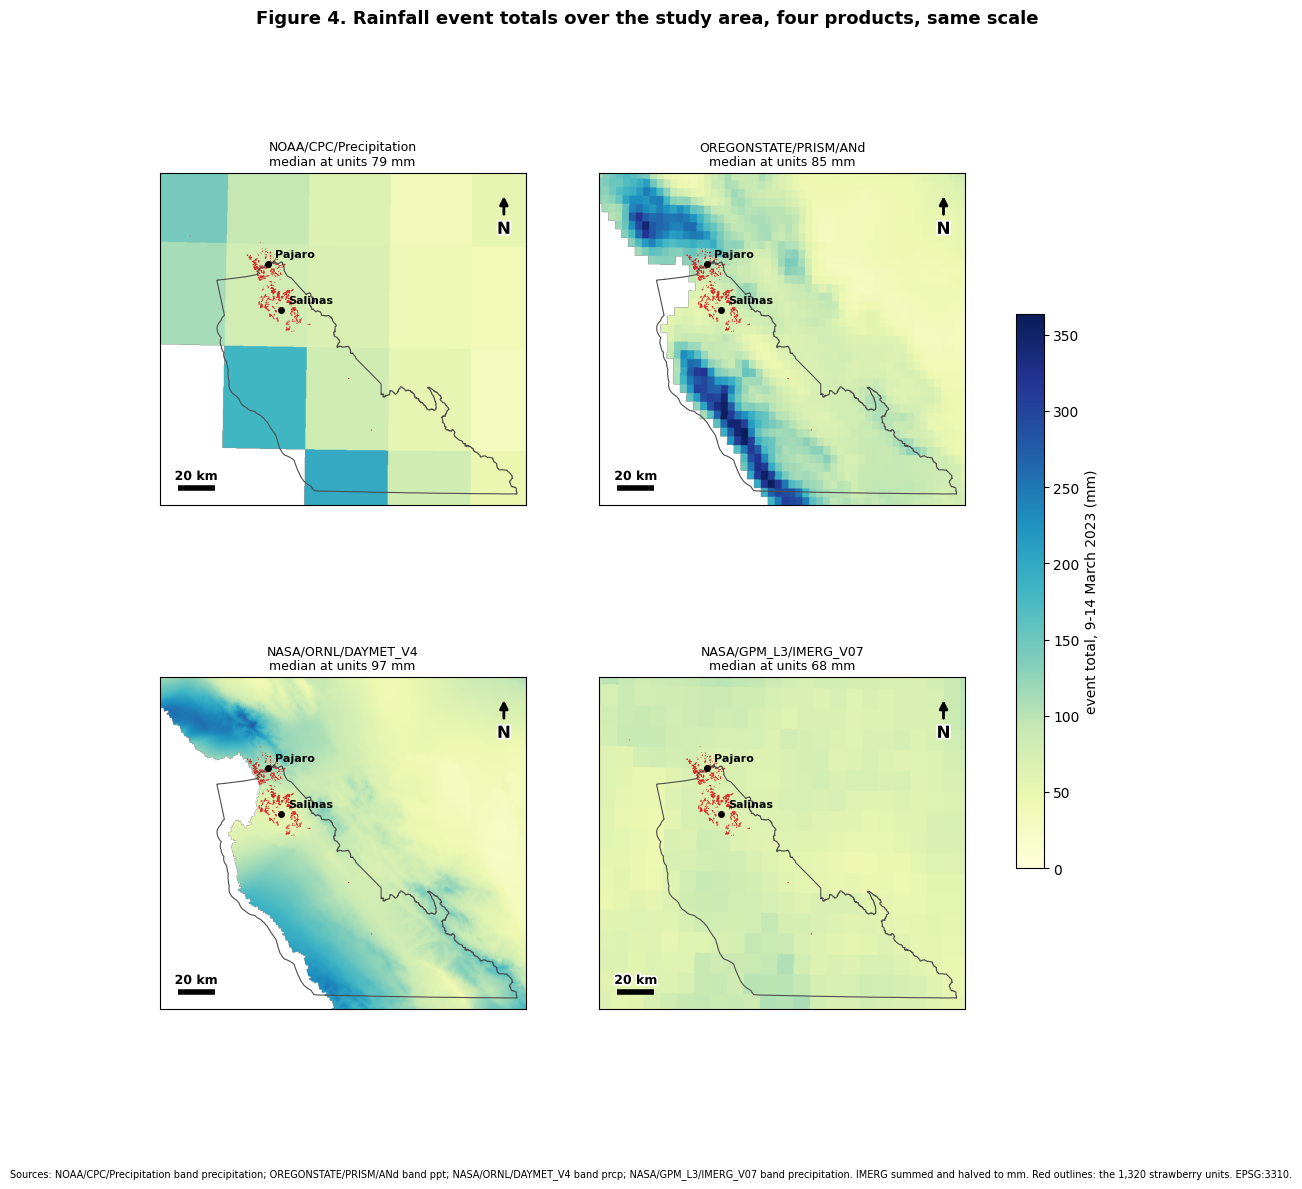

Saved fig4_rainfall_products.png
n units = 1320 | date window: 2023-03-09 to 2023-03-14 | datasets: NOAA/CPC/Precipitation, OREGONSTATE/PRISM/ANd, NASA/ORNL/DAYMET_V4, NASA/GPM_L3/IMERG_V07


In [6]:
BBOX = tuple(np.round(counties.total_bounds + np.array([-0.05, -0.05, 0.05, 0.05]), 3))
arrs = {}
for key in C.RAIN:
    arr, ext = ee_tif(total(key, *EVENT, key).toFloat(),
                      C.DERIVED / f"04_{key}_event_mm.tif", BBOX, 250)
    arrs[key] = np.ma.masked_invalid(arr)
vmax = float(np.nanmax([a.max() for a in arrs.values()]))
vmin = 0.0
print(f"colour scale 0 to {vmax:.0f} mm, shared across panels")

fig, axes = plt.subplots(2, 2, figsize=(13, 12))
units_gdf = gpd.read_file(C.DERIVED / "01_units_dwr.geojson", engine="fiona").to_crs(C.GRID_CRS)
units_gdf = units_gdf[units_gdf.is_unit.astype(bool)]
for ax, key in zip(axes.ravel(), C.RAIN):
    im = ax.imshow(arrs[key], extent=ext, origin="upper", cmap="YlGnBu", vmin=vmin, vmax=vmax)
    counties_m.boundary.plot(ax=ax, color="0.3", lw=0.8)
    units_gdf.plot(ax=ax, color="none", edgecolor="tab:red", lw=0.3)
    for _, t in towns.iterrows():
        ax.plot(t.geometry.x, t.geometry.y, marker="o", ms=4, color="black")
        ax.annotate(t["name"], (t.geometry.x, t.geometry.y), xytext=(5, 5),
                    textcoords="offset points", fontsize=8, fontweight="bold")
    ax.set_xlim(ext[0], ext[1])
    ax.set_ylim(ext[2], ext[3])
    ax.set_xticks([])
    ax.set_yticks([])
    med = rain[key + "_event"].median()
    ax.set_title(f"{C.RAIN[key][0]}\nmedian at units {med:.0f} mm", fontsize=9)
    add_scale_bar(ax, 20, color="black")
    add_north_arrow(ax, color="black")
cb = fig.colorbar(im, ax=axes, shrink=0.6, label="event total, 9-14 March 2023 (mm)")
fig.suptitle("Figure 4. Rainfall event totals over the study area, four products, same scale",
             fontsize=13, fontweight="bold")
fig.text(0.01, 0.005,
         "Sources: " + "; ".join(f"{v[0]} band {v[1]}" for v in C.RAIN.values())
         + ". IMERG summed and halved to mm. Red outlines: the 1,320 strawberry units. EPSG:3310.",
         fontsize=7, va="bottom")
FIG = C.FIGURES / "fig4_rainfall_products.png"
fig.savefig(FIG, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {FIG.name}")
print(f"n units = {N_UNITS} | date window: {EVENT[0]} to 2023-03-14 | datasets: "
      + ", ".join(v[0] for v in C.RAIN.values()))